# RL Physical Design Router — Environment Setup

Outline
- 1.1 Dependency installation & imports
- 1.2 Custom 5×5 routing grid environment
- 1.3 Net configuration generation
- 1.4 A* initial router
- 1.5 Reward function
- 1.6 Grid visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import heapq
import itertools
import random
from copy import deepcopy
from typing import List, Tuple, Dict, Optional

try:
    import gymnasium as gym
    from gymnasium import spaces
    GYM_AVAILABLE = True
    print("gymnasium available")
except ImportError:
    GYM_AVAILABLE = False
    print("gymnasium not installed — using standalone GridEnv")

print("NumPy:", np.__version__)
print("All imports OK")

gymnasium available
NumPy: 2.2.6
All imports OK


## 1.2: Grid configuration constants

In [2]:
# Grid and Net configuration
GRID_SIZE  = 5          # 5×5 routing grid (from Gandhi et al. 2019)
NUM_NETS   = 3          # 3 nets to route
PINS_PER_NET = 2        # each net has 2 pins (source + sink)

# Channel indices for state tensor
# State shape: (NUM_NETS * 2 + 1, GRID_SIZE, GRID_SIZE)
#   Channels 0..NUM_NETS-1  : net path occupancy (one channel per net)
#   Channels NUM_NETS..2*NUM_NETS-1 : pin locations (one channel per net)
#   Channel 2*NUM_NETS      : congestion / overlap map
C_PATH_START = 0
C_PIN_START  = NUM_NETS
C_CONGESTION = NUM_NETS * 2
NUM_CHANNELS = NUM_NETS * 2 + 1

# Action space
ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}  # up, down, left, right
ACTION_NAMES = {0: "UP", 1: "DOWN", 2: "LEFT", 3: "RIGHT"}

# Reward shaping
REWARD_ROUTE_COMPLETE  =  10.0   # all nets connected, no overlap
REWARD_STEP_PENALTY    =  -0.1   # small cost per step (encourages shorter paths)
REWARD_OVERLAP_PENALTY =  -5.0   # per overlapping cell
REWARD_DRC_VIOLATION   =  -2.0   # design rule violation penalty

print(f"Grid: {GRID_SIZE}×{GRID_SIZE}  |  Nets: {NUM_NETS}  |  Channels: {NUM_CHANNELS}")
print(f"State tensor shape: ({NUM_CHANNELS}, {GRID_SIZE}, {GRID_SIZE})")

Grid: 5×5  |  Nets: 3  |  Channels: 7
State tensor shape: (7, 5, 5)


## 1.3: Net Configuration Generator

Enumerate all valid pin placements for 3 nets × 2 pins on the 5×5 grid.
Gandhi et al. report ~157 valid combinations.

In [4]:
def generate_net_configs(
    grid_size: int = GRID_SIZE,
    num_nets: int = NUM_NETS,
    min_manhattan: int = 2,
    seed: Optional[int] = None
) -> List[List[Tuple[Tuple[int,int], Tuple[int,int]]]]:
    """
    Generate all valid net pin configurations.

    Each configuration is a list of (source, sink) pin pairs, one per net.
    Pins must be:
      - Distinct across all nets
      - At least `min_manhattan` apart within each net

    Returns a list of configurations.
    """
    if seed is not None:
        random.seed(seed)

    all_cells = [(r, c) for r in range(grid_size) for c in range(grid_size)]
    configs = []

    # Choose 2*num_nets distinct cells, then assign as pin pairs
    for pin_cells in itertools.combinations(all_cells, num_nets * PINS_PER_NET):
        # Try pairing cells as (net0_src, net0_snk), (net1_src, net1_snk), ...
        valid = True
        nets = []
        for i in range(num_nets):
            src = pin_cells[i * 2]
            snk = pin_cells[i * 2 + 1]
            manhattan = abs(src[0]-snk[0]) + abs(src[1]-snk[1])
            if manhattan < min_manhattan:
                valid = False
                break
            nets.append((src, snk))
        if valid:
            configs.append(nets)

    return configs


all_configs = generate_net_configs(seed=42)
print(f"Total valid net configurations: {len(all_configs)}")
print(f"\nExample configuration (first 3):")
for i, cfg in enumerate(all_configs[:3]):
    print(f"  Config {i}: ", [(f"Net{j}", src, "to", snk) for j, (src, snk) in enumerate(cfg)])

Total valid net configurations: 60823

Example configuration (first 3):
  Config 0:  [('Net0', (0, 0), 'to', (0, 2)), ('Net1', (0, 3), 'to', (1, 0)), ('Net2', (1, 1), 'to', (1, 3))]
  Config 1:  [('Net0', (0, 0), 'to', (0, 2)), ('Net1', (0, 3), 'to', (1, 0)), ('Net2', (1, 1), 'to', (1, 4))]
  Config 2:  [('Net0', (0, 0), 'to', (0, 2)), ('Net1', (0, 3), 'to', (1, 0)), ('Net2', (1, 1), 'to', (2, 0))]


## 1.4: A* Router

Used to generate initial (overlapping) solutions before the Cleaner + Router agents take over.

In [6]:
def heuristic(a: Tuple[int,int], b: Tuple[int,int]) -> int:
    """Manhattan distance heuristic for A*."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def astar(
    grid_size: int,
    source: Tuple[int,int],
    sink: Tuple[int,int],
    blocked: Optional[set] = None
) -> Optional[List[Tuple[int,int]]]:
    """
    A* pathfinding on a 2D grid.

    Args:
        grid_size: side length of the square grid
        source:    (row, col) start cell
        sink:      (row, col) target cell
        blocked:   set of (row, col) cells that cannot be used

    Returns:
        List of (row, col) cells from source to sink (inclusive),
        or None if no path exists.
    """
    if blocked is None:
        blocked = set()

    open_heap = []  # min-heap: (f_score, g_score, cell)
    heapq.heappush(open_heap, (heuristic(source, sink), 0, source))

    came_from: Dict[Tuple, Optional[Tuple]] = {source: None}
    g_score: Dict[Tuple, int] = {source: 0}

    while open_heap:
        _, g, current = heapq.heappop(open_heap)

        if current == sink:
            # Reconstruct path
            path = []
            node = sink
            while node is not None:
                path.append(node)
                node = came_from[node]
            return path[::-1]

        if g > g_score.get(current, float('inf')):
            continue

        r, c = current
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            neighbor = (r + dr, c + dc)
            nr, nc = neighbor
            if not (0 <= nr < grid_size and 0 <= nc < grid_size):
                continue
            if neighbor in blocked:
                continue
            new_g = g + 1
            if new_g < g_score.get(neighbor, float('inf')):
                g_score[neighbor] = new_g
                f = new_g + heuristic(neighbor, sink)
                heapq.heappush(open_heap, (f, new_g, neighbor))
                came_from[neighbor] = current

    return None  # No path found


def route_all_nets_astar(
    grid_size: int,
    nets: List[Tuple[Tuple[int,int], Tuple[int,int]]]
) -> List[Optional[List[Tuple[int,int]]]]:
    """
    Route all nets sequentially with A*.
    Note: nets are routed one by one; earlier nets block later ones,
    producing realistic overlaps when routed without awareness of others.
    """
    paths = []
    # For initial overlapping solution: do NOT block previous paths
    for src, snk in nets:
        path = astar(grid_size, src, snk, blocked=set())
        paths.append(path)
    return paths


# Quick test
test_nets = all_configs[0]
test_paths = route_all_nets_astar(GRID_SIZE, test_nets)
print("A* test paths for config 0:")
for i, (net, path) in enumerate(zip(test_nets, test_paths)):
    print(f"  Net {i}: {net[0]} to {net[1]} | path length: {len(path) if path else 'FAILED'}")

A* test paths for config 0:
  Net 0: (0, 0) to (0, 2) | path length: 3
  Net 1: (0, 3) to (1, 0) | path length: 5
  Net 2: (1, 1) to (1, 3) | path length: 3


## 1.5: Grid State and Reward Function

In [7]:
def build_state_tensor(
    nets: List[Tuple[Tuple[int,int], Tuple[int,int]]],
    paths: List[Optional[List[Tuple[int,int]]]],
    grid_size: int = GRID_SIZE
) -> np.ndarray:
    """
    Build the multi-channel state tensor from net definitions and current paths.

    Shape: (NUM_CHANNELS, grid_size, grid_size)
      - Channels 0..NUM_NETS-1         : path occupancy per net
      - Channels NUM_NETS..2*NUM_NETS-1 : pin locations per net
      - Channel 2*NUM_NETS             : congestion (overlap count)
    """
    state = np.zeros((NUM_CHANNELS, grid_size, grid_size), dtype=np.float32)

    for net_idx, (path, (src, snk)) in enumerate(zip(paths, nets)):
        # Pin channel
        state[C_PIN_START + net_idx, src[0], src[1]] = 1.0
        state[C_PIN_START + net_idx, snk[0], snk[1]] = 1.0

        # Path channel
        if path:
            for (r, c) in path:
                state[C_PATH_START + net_idx, r, c] = 1.0

    # Congestion channel: sum of all path layers
    path_layers = state[C_PATH_START:C_PATH_START + NUM_NETS]
    state[C_CONGESTION] = path_layers.sum(axis=0)

    return state


def compute_overlaps(state: np.ndarray) -> int:
    """Count grid cells where more than one net shares the same path cell."""
    congestion = state[C_CONGESTION]
    return int(np.sum(congestion > 1))


def compute_total_wirelength(paths: List[Optional[List]]) -> int:
    """Total number of edges across all routed paths."""
    return sum(len(p) - 1 for p in paths if p)


def compute_reward(
    state: np.ndarray,
    paths: List[Optional[List]],
    nets: List[Tuple]
) -> float:
    """
    Compute reward signal for the current routing state.

    Reward components:
      + REWARD_ROUTE_COMPLETE  if all nets routed with zero overlaps
      + REWARD_STEP_PENALTY    per routing step (penalizes long paths)
      + REWARD_OVERLAP_PENALTY per overlapping cell
    """
    overlaps = compute_overlaps(state)
    wirelength = compute_total_wirelength(paths)
    all_routed = all(p is not None for p in paths)

    reward = 0.0
    reward += REWARD_STEP_PENALTY * wirelength
    reward += REWARD_OVERLAP_PENALTY * overlaps

    if all_routed and overlaps == 0:
        reward += REWARD_ROUTE_COMPLETE

    return reward


# Test state construction
test_state = build_state_tensor(test_nets, test_paths)
print(f"State tensor shape: {test_state.shape}")
print(f"Overlapping cells : {compute_overlaps(test_state)}")
print(f"Total wirelength  : {compute_total_wirelength(test_paths)}")
print(f"Reward            : {compute_reward(test_state, test_paths, test_nets):.2f}")

State tensor shape: (7, 5, 5)
Overlapping cells : 3
Total wirelength  : 8
Reward            : -15.80


## 1.6: Routing Grid Environment

In [9]:
class GridEnv:
    """
    5×5 IC Routing Grid Environment.

    Follows the Gandhi et al. (2019) two-agent cooperative game:
      - Cleaner selects a net to remove (breaks overlapping path)
      - Router re-routes the broken net

    This environment supports both agents via mode switching.
    """

    def __init__(
        self,
        configs: List = None,
        grid_size: int = GRID_SIZE,
        seed: Optional[int] = None
    ):
        self.grid_size = grid_size
        self.configs   = configs or generate_net_configs(seed=seed)
        self.rng       = np.random.default_rng(seed)

        # State placeholders
        self.nets:   List = []
        self.paths:  List = []
        self.state:  np.ndarray = None
        self.done:   bool = False
        self.steps:  int = 0

    # Core API 

    def reset(self, config_idx: Optional[int] = None) -> np.ndarray:
        """
        Reset to a new net configuration and run A* for initial routing.
        Returns the initial state tensor.
        """
        if config_idx is None:
            config_idx = int(self.rng.integers(0, len(self.configs)))

        self.nets   = deepcopy(self.configs[config_idx])
        self.paths  = route_all_nets_astar(self.grid_size, self.nets)
        self.state  = build_state_tensor(self.nets, self.paths, self.grid_size)
        self.done   = False
        self.steps  = 0
        return self.state.copy()

    # Cleaner action 

    def cleaner_step(self, net_to_remove: int) -> Tuple[np.ndarray, float, bool]:
        """
        Cleaner action: remove the path of `net_to_remove`.

        Args:
            net_to_remove: index of net whose path is cleared

        Returns:
            (next_state, reward, done)
        """
        assert 0 <= net_to_remove < NUM_NETS, f"Invalid net index: {net_to_remove}"
        self.paths[net_to_remove] = None
        self.state = build_state_tensor(self.nets, self.paths, self.grid_size)
        reward = compute_reward(self.state, self.paths, self.nets)
        self.steps += 1
        return self.state.copy(), reward, self.done

    # Router action 

    def router_step(
        self,
        net_idx: int,
        new_path: List[Tuple[int,int]]
    ) -> Tuple[np.ndarray, float, bool]:
        """
        Router action: assign a new path for `net_idx`.

        Args:
            net_idx:  index of the net being re-routed
            new_path: list of (row, col) cells

        Returns:
            (next_state, reward, done)
        """
        self.paths[net_idx] = new_path
        self.state = build_state_tensor(self.nets, self.paths, self.grid_size)
        reward = compute_reward(self.state, self.paths, self.nets)
        overlaps = compute_overlaps(self.state)
        all_routed = all(p is not None for p in self.paths)
        self.done = all_routed and overlaps == 0
        self.steps += 1
        return self.state.copy(), reward, self.done

    # Utilities 

    def get_info(self) -> dict:
        return {
            "steps":       self.steps,
            "overlaps":    compute_overlaps(self.state),
            "wirelength":  compute_total_wirelength(self.paths),
            "all_routed":  all(p is not None for p in self.paths),
            "done":        self.done,
        }


# Smoke test
env = GridEnv(configs=all_configs, seed=42)
state = env.reset(config_idx=0)
info = env.get_info()
print("Environment reset OK")
print(f"  State shape : {state.shape}")
print(f"  Overlaps    : {info['overlaps']}")
print(f"  Wirelength  : {info['wirelength']}")
print(f"  All routed  : {info['all_routed']}")

Environment reset OK
  State shape : (7, 5, 5)
  Overlaps    : 3
  Wirelength  : 8
  All routed  : True


## 1.7: Grid Visualization

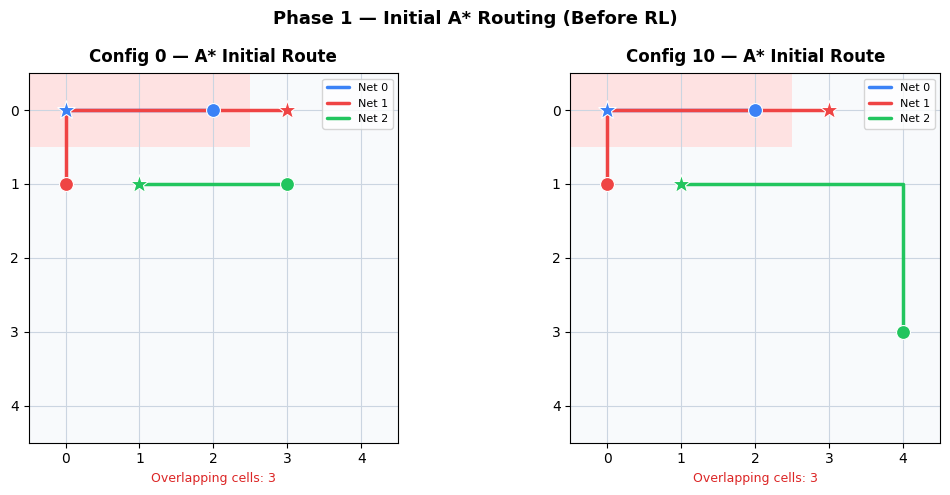

Grid visualization saved


In [10]:
NET_COLORS = ['#3B82F6', '#EF4444', '#22C55E']  # blue, red, green
PIN_MARKER_SIZE = 14

def render_grid(
    nets: List,
    paths: List,
    grid_size: int = GRID_SIZE,
    title: str = "Routing Grid",
    ax: Optional[plt.Axes] = None
):
    """
    Render the routing grid with net paths and pin markers.

    - Colored lines show each net's routed path
    - Stars mark source pins; circles mark sink pins
    - Red background highlights overlapping cells
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    # Background grid
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(-0.5, grid_size - 0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.grid(True, color='#CBD5E1', linewidth=0.8, zorder=0)
    ax.set_facecolor('#F8FAFC')

    # Build overlap map
    overlap_map = np.zeros((grid_size, grid_size), dtype=int)
    for path in paths:
        if path:
            for (r, c) in path:
                overlap_map[r, c] += 1

    # Highlight overlapping cells
    for r in range(grid_size):
        for c in range(grid_size):
            if overlap_map[r, c] > 1:
                ax.add_patch(mpatches.Rectangle(
                    (c - 0.5, r - 0.5), 1, 1,
                    facecolor='#FEE2E2', edgecolor='none', zorder=1
                ))

    # Draw paths
    for net_idx, (path, color) in enumerate(zip(paths, NET_COLORS)):
        if path:
            xs = [c for (r, c) in path]
            ys = [r for (r, c) in path]
            ax.plot(xs, ys, color=color, linewidth=2.5, zorder=2,
                    label=f'Net {net_idx}', solid_capstyle='round')

    # Draw pins
    for net_idx, ((src, snk), color) in enumerate(zip(nets, NET_COLORS)):
        ax.plot(src[1], src[0], marker='*', markersize=PIN_MARKER_SIZE,
                color=color, zorder=4, markeredgecolor='white', markeredgewidth=0.8)
        ax.plot(snk[1], snk[0], marker='o', markersize=PIN_MARKER_SIZE - 4,
                color=color, zorder=4, markeredgecolor='white', markeredgewidth=0.8)

    # Invert y-axis so (0,0) is top-left
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.8)

    total_overlaps = int(np.sum(overlap_map > 1))
    ax.set_xlabel(f"Overlapping cells: {total_overlaps}", fontsize=9, color='#DC2626')
    return ax


# Render the test routing state
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Phase 1 — Initial A* Routing (Before RL)", fontsize=13, fontweight='bold')

render_grid(test_nets, test_paths, title="Config 0 — A* Initial Route", ax=axes[0])

# Show a second random config
env2 = GridEnv(configs=all_configs, seed=7)
env2.reset(config_idx=10)
render_grid(env2.nets, env2.paths, title="Config 10 — A* Initial Route", ax=axes[1])

plt.tight_layout()
plt.savefig('phase1_grid_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("Grid visualization saved")

In [11]:
print("=" * 55)
print("  Sanity Check: Cleaner → Router Loop")
print("=" * 55)

env_test = GridEnv(configs=all_configs, seed=0)
state = env_test.reset(config_idx=5)
info = env_test.get_info()

print(f"\n[RESET] Config 5")
print(f"  Overlaps   : {info['overlaps']}")
print(f"  Wirelength : {info['wirelength']}")

# Cleaner removes net with most overlapping cells
congestion = state[C_CONGESTION]
overlap_per_net = []
for net_idx in range(NUM_NETS):
    path_layer = state[C_PATH_START + net_idx]
    overlap_count = int(np.sum((path_layer > 0) & (congestion > 1)))
    overlap_per_net.append(overlap_count)

net_to_clean = int(np.argmax(overlap_per_net))
print(f"\n[CLEANER] Removing Net {net_to_clean} "
      f"(overlap score: {overlap_per_net[net_to_clean]})")

state, reward, done = env_test.cleaner_step(net_to_clean)
info = env_test.get_info()
print(f"  Post-clean overlaps   : {info['overlaps']}")
print(f"  Reward                : {reward:.2f}")

# Router re-routes using A*
src, snk = env_test.nets[net_to_clean]
new_path = astar(GRID_SIZE, src, snk, blocked=set())
print(f"\n[ROUTER] Re-routing Net {net_to_clean}: {src} → {snk}")
print(f"  New path length: {len(new_path) if new_path else 'FAILED'}")

state, reward, done = env_test.router_step(net_to_clean, new_path)
info = env_test.get_info()
print(f"\n[RESULT]")
print(f"  Overlaps after re-route : {info['overlaps']}")
print(f"  Wirelength              : {info['wirelength']}")
print(f"  Reward                  : {reward:.2f}")
print(f"  Done                    : {done}")
print()
print("Cleaner Router loop working")

  Sanity Check: Cleaner → Router Loop

[RESET] Config 5
  Overlaps   : 3
  Wirelength : 10

[CLEANER] Removing Net 0 (overlap score: 3)
  Post-clean overlaps   : 0
  Reward                : -0.80

[ROUTER] Re-routing Net 0: (0, 0) → (0, 2)
  New path length: 3

[RESULT]
  Overlaps after re-route : 3
  Wirelength              : 10
  Reward                  : -16.00
  Done                    : False

Cleaner Router loop working
